# Módulo 7 · Clase 3 — La red que ve

**Machine Learning for Petroleum Engineers Using Python** · SLB Ecuador / UDLA

---

### El arco de esta parte

Acaban de ver el flujo completo con el Titanic: los **árboles** ganaron.
Ahora tres preguntas, en orden:

1. ¿Y una **red neuronal** le ganaría al boosting en esa misma tabla?
2. ¿Qué puede hacer una red que una recta **no puede**? (la no linealidad,
   vista con los ojos)
3. ¿Y dónde brillan de verdad las redes? — donde **no hay tabla**: su
   primera red que **lee dígitos escritos a mano**, y el salto de 2026:
   modelos ya entrenados por otros, dirigidos por ustedes.

### Cómo se trabaja este cuaderno

**Guiado, como en la Clase 1:** la carga de datos viene dada, cada paso trae
su **prompt** para pegarle al agente de Gemini (✨), y la celda de trabajo
está vacía. Lo construimos juntos, en vivo.

> Regla de siempre: lo que devuelva el agente se **revisa** contra el
> criterio de aceptación antes de celebrar.

## 0 · Preparación *(dada)*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATOS = "https://raw.githubusercontent.com/cmosquerat/slb-diplomado/main/datos/"
SEMILLA = 0

try:
    import google.colab              # noqa: F401
    EN_COLAB = True
except ImportError:
    EN_COLAB = False

print("listo. ¿en Colab?", EN_COLAB)

listo. ¿en Colab? False


---

# Parte 1 · ¿La red le gana al bosque?

**El récord a batir** — la celda de abajo reconstruye el ganador de la demo
(mismo dato, misma limpieza, misma semilla) y le toma el examen. *(dada)*

In [2]:
# --- DADA: el titanic limpio y el campeon de la demo, para tener el record
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

pasajeros = pd.read_csv(DATOS + "pasajeros_titanic.csv")
t = pasajeros[["survived", "pclass", "sex", "age",
               "sibsp", "parch", "fare", "embarked"]].copy()
t["age"] = t.age.fillna(t.age.median())
t["embarked"] = t.embarked.fillna(t.embarked.mode()[0])

X = pd.get_dummies(t.drop(columns="survived"), columns=["sex", "embarked"])
y = t.survived
X_ent, X_exa, y_ent, y_exa = train_test_split(
    X, y, test_size=0.2, random_state=SEMILLA, stratify=y)

campeon = HistGradientBoostingClassifier(
    learning_rate=0.05, max_leaf_nodes=31, random_state=SEMILLA)
campeon.fit(X_ent, y_ent)
RECORD = accuracy_score(y_exa, campeon.predict(X_exa))
print(f"EL RÉCORD A BATIR (gradient boosting): {RECORD:.3f}")

EL RÉCORD A BATIR (gradient boosting): 0.816


**Su encargo.** Peguen esto al agente — fíjense que le damos todo el
contexto y le fijamos el examen para que la comparación sea justa:

```
CONTEXTO: en este cuaderno tengo X_ent, X_exa, y_ent, y_exa (Titanic
limpio, 10 columnas numéricas, examen del 20% estratificado con semilla
0). El récord a batir es RECORD, de un gradient boosting.

OBJETIVO: una red neuronal en Keras para la misma tarea, y compararla
contra el récord EN EL MISMO examen.

RESTRICCIONES:
- normaliza las entradas (StandardScaler ajustado SOLO con X_ent)
- red pequeña: dos capas ocultas con activación relu, salida sigmoid
- entrena máximo 100 épocas con validation_split=0.15 y early stopping
- semillas fijas (tf.random.set_seed(0), numpy 0)

CRITERIO DE ACEPTACIÓN:
- imprime los dos números lado a lado: red vs récord
- nada de tocar X_exa hasta el examen final
```

**Tarea (anoten antes de correr):** ¿quién creen que gana, y por cuánto?

In [3]:
# ✍️ aqui va lo que devuelva el agente

**Puesta en común de la apuesta:** ¿ganó la red? *(En mis corridas: no — y
eso no es un fracaso de la red, es la lección.)*

> **La lección honesta de 2026:** en datos **tabulares** — filas y columnas,
> como casi todo lo que ustedes manejan — los árboles (bosques, boosting)
> siguen mandando. Las redes neuronales brillan donde **no hay tabla**:
> imágenes, señales, texto. Vamos allá.

---

# Parte 2 · La no linealidad, vista con los ojos

¿Qué tiene una red por dentro que un modelo lineal no? La respuesta se
puede **ver**. La celda de abajo genera un dataset de juguete: dos medias
lunas entrelazadas. *(dada)*

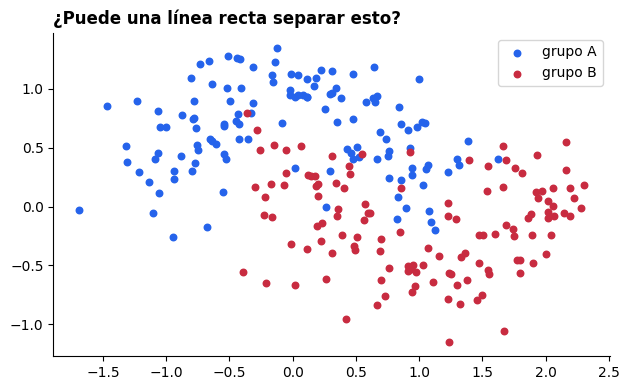

In [4]:
# --- DADA: dos medias lunas que ninguna recta puede separar
from sklearn.datasets import make_moons

puntos, etiqueta = make_moons(n_samples=250, noise=0.25, random_state=SEMILLA)

fig, ax = plt.subplots(figsize=(6.4, 4))
ax.scatter(puntos[etiqueta == 0, 0], puntos[etiqueta == 0, 1],
           c="#2563EB", s=22, label="grupo A")
ax.scatter(puntos[etiqueta == 1, 0], puntos[etiqueta == 1, 1],
           c="#C82B40", s=22, label="grupo B")
ax.legend()
ax.set_title("¿Puede una línea recta separar esto?", loc="left",
             fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

**Su encargo:**

```
CONTEXTO: tengo `puntos` (250 filas, 2 columnas) y `etiqueta` (0/1) de
make_moons: dos medias lunas entrelazadas.

OBJETIVO: mostrar visualmente qué puede y qué no puede cada modelo.
- entrena una LogisticRegression y un MLPClassifier
  (hidden_layer_sizes=(16, 16), max_iter=3000, random_state=0)
- dibuja las dos FRONTERAS DE DECISIÓN lado a lado, con los puntos
  encima, títulos en español, y el acierto de cada uno en el título

CRITERIO DE ACEPTACIÓN:
- que se VEA de un vistazo cuál de los dos puede curvar la frontera
```

**Tarea:** cuando salga, respondan en una frase cada una: ¿por qué la
recta no puede? ¿qué le permite a la red curvarse?

In [5]:
# ✍️ aqui va lo que devuelva el agente

**La respuesta corta, para el cuaderno de apuntes:** una regresión logística
solo puede trazar **una recta** (un plano, en más dimensiones). Una red
apila neuronas — cada una es *suma ponderada + activación* — y esa
activación (el «doblez» de la relu) es lo que le permite **componer curvas**.
Más capas y neuronas: fronteras más flexibles. Ese es todo el secreto.

---

# Parte 3 · Su primera red de verdad: leer dígitos a mano

**MNIST**: 70.000 dígitos escritos a mano, el «hola mundo» de las redes
neuronales desde hace treinta años. Cada dígito es una imagen de 28×28
píxeles — **no hay tabla**: hay 784 pixeles con estructura.

La carga viene dada *(en Colab, Keras ya está instalado)*:

/private/tmp/claude-501/-Users-cmosquerat-Documents-GitHub-slb-diplomado/17ff0dd6-d936-43c0-bd10-f0fc4e571d53/scratchpad/v7/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


entrenamiento: (60000, 28, 28) | examen: (10000, 28, 28)
cada imagen: 28x28 pixeles, valores 0 a 255


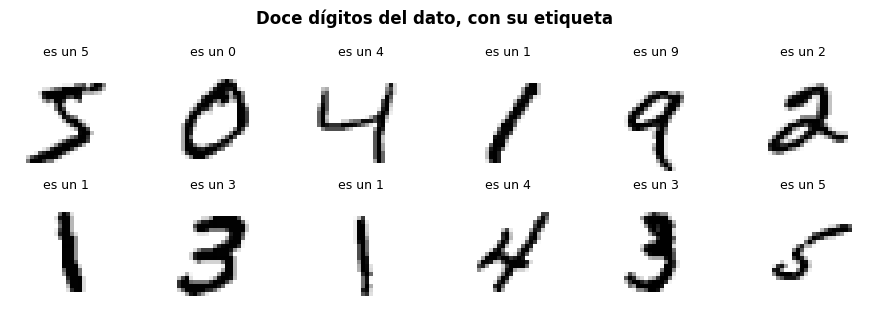

In [6]:
# --- DADA: cargar MNIST y mirar el dato antes de modelar (la regla de oro)
try:
    from tensorflow import keras
    (x_ent, y_ent), (x_exa, y_exa) = keras.datasets.mnist.load_data()
    print(f"entrenamiento: {x_ent.shape} | examen: {x_exa.shape}")
    print(f"cada imagen: {x_ent.shape[1]}x{x_ent.shape[2]} pixeles, "
          f"valores {x_ent.min()} a {x_ent.max()}")

    fig, axes = plt.subplots(2, 6, figsize=(9, 3.2))
    for ax, i in zip(axes.ravel(), range(12)):
        ax.imshow(x_ent[i], cmap="gray_r")
        ax.set_title(f"es un {y_ent[i]}", fontsize=9)
        ax.axis("off")
    plt.suptitle("Doce dígitos del dato, con su etiqueta", fontweight="bold")
    plt.tight_layout(); plt.show()
except ImportError:
    print("TensorFlow no está en este entorno; en Colab ya viene instalado.")

Fíjense en el rango: los píxeles van de **0 a 255**. Ahí aparece la
**normalización** del contrato de esta clase: las redes entrenan mal con
números grandes y desparejos — todo se lleva a 0–1 dividiendo por 255.

**Su encargo (a) — armar y entrenar la red:**

```
CONTEXTO: tengo x_ent, y_ent, x_exa, y_exa de keras.datasets.mnist.
Imágenes de 28x28 con píxeles 0-255; etiquetas 0-9.

OBJETIVO: mi primera red neuronal en Keras que clasifique los dígitos.

RESTRICCIONES:
- normaliza dividiendo por 255, y aplana cada imagen a 784 valores
- red simple: Dense(128, relu) -> Dense(10, softmax)
- compila con adam y sparse_categorical_crossentropy, mide accuracy
- entrena 8 épocas con validation_split=0.1, semilla tf 0
- guarda el history en una variable

CRITERIO DE ACEPTACIÓN:
- más de 97% de acierto en validación
- al final, el examen con x_exa UNA sola vez
```

**Tarea:** mientras entrena, miren la barra época por época — están viendo
a la red **aprender**.

In [7]:
# ✍️ aqui va lo que devuelva el agente

**Su encargo (b) — ver el overfitting con sus propios ojos:**

```
Con el `history` del entrenamiento anterior: grafica accuracy y loss de
entrenamiento y de validación por época, lado a lado, en español.
Marca visualmente la zona donde el entrenamiento sigue mejorando pero
la validación ya no.
```

**Tarea:** ¿en qué época se separan las curvas? Esa separación **es** el
overfitting del contrato de esta clase: la red empieza a memorizar en vez
de aprender. La medicina se llama *regularización* — parar antes (early
stopping), o penalizar la complejidad.

In [8]:
# ✍️ aqui va lo que devuelva el agente

**Su encargo (c) — la parte honesta: ¿en qué se equivoca?**

```
Con la red entrenada y el examen x_exa:
- la matriz de confusión 10x10
- muéstrame 9 dígitos donde la red se equivocó, con lo que ella creyó,
  su confianza, y la etiqueta real
```

**Tarea:** ¿qué pares se confunden (¿4 y 9? ¿3 y 5?)? ¿Los errores son
razonables — se equivocaría también un humano con esa caligrafía?

In [9]:
# ✍️ aqui va lo que devuelva el agente

---

# 🛠️ Su reto · La misma red, otra ropa

**Fashion-MNIST**: 70.000 prendas de ropa en imágenes de 28×28 — el
reemplazo moderno de los dígitos, con exactamente las mismas formas. La
carga viene dada; **todo lo demás es de ustedes**.

Y hay un cambio de nivel: en MNIST los prompts se los di yo. Esta vez
**los escriben ustedes**, con la plantilla de la Clase 1 (contexto,
objetivo, restricciones, criterio de aceptación).

> En clase si alcanza el tiempo; si no, para la casa — es el mejor
> calentamiento posible para la entrega del jueves.

    0/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


       0/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   16384/26421880 ━━━━━━━━━━━━━━━━━━━━ 1:28 3us/step

   49152/26421880 ━━━━━━━━━━━━━━━━━━━━ 1:09 3us/step

...

2760704/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

3366912/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

3923968/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


entrenamiento: (60000, 28, 28) | examen: (10000, 28, 28)


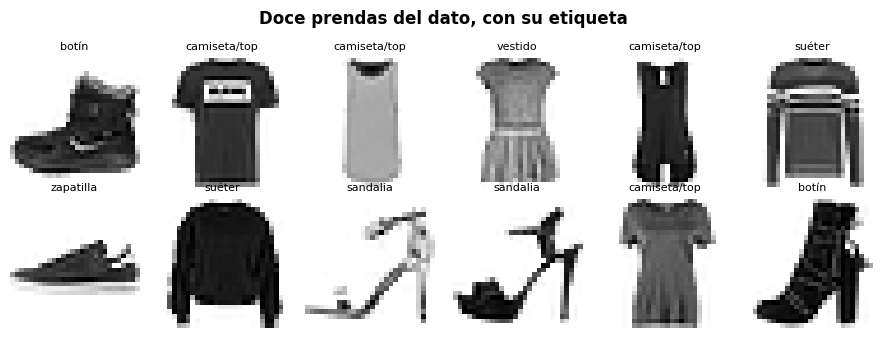

In [10]:
# --- DADA: cargar Fashion-MNIST y mirar el dato (la regla de oro)
PRENDAS = ["camiseta/top", "pantalón", "suéter", "vestido", "abrigo",
           "sandalia", "camisa", "zapatilla", "bolso", "botín"]

try:
    from tensorflow import keras
    (xf_ent, yf_ent), (xf_exa, yf_exa) = \
        keras.datasets.fashion_mnist.load_data()
    print(f"entrenamiento: {xf_ent.shape} | examen: {xf_exa.shape}")

    fig, axes = plt.subplots(2, 6, figsize=(9, 3.4))
    for ax, i in zip(axes.ravel(), range(12)):
        ax.imshow(xf_ent[i], cmap="gray_r")
        ax.set_title(PRENDAS[yf_ent[i]], fontsize=8)
        ax.axis("off")
    plt.suptitle("Doce prendas del dato, con su etiqueta", fontweight="bold")
    plt.tight_layout(); plt.show()
except ImportError:
    print("TensorFlow no está en este entorno; en Colab ya viene instalado.")

**El encargo, completo:** repitan el flujo de la Parte 3 sobre este dato —
armar y entrenar la red, las curvas de entrenamiento contra validación, y
los errores mirados a la cara. Con sus propios prompts.

**Cómo saber si van bien** (preguntas, no respuestas):

- La **misma arquitectura** que leyó dígitos: ¿rinde igual acá? ¿Cuánto da,
  y qué les dice la diferencia sobre *dónde vive la dificultad*?
- ¿En qué época empieza **ahora** el overfitting? ¿Antes o después que con
  los dígitos?
- ¿Qué **prendas se confunden** entre sí? Miren esas imágenes: ¿los
  confundirían también a ustedes? ¿Qué implicaría eso si esta red etiquetara
  inventario?

*(Sin solución escrita, como siempre: se discute en la puesta en común — o
en la Clase 4 si queda de tarea.)*

In [11]:
# ✍️ su prompt y el codigo del agente: armar y entrenar

In [12]:
# ✍️ su prompt y el codigo del agente: las curvas

In [13]:
# ✍️ su prompt y el codigo del agente: los errores

---

# Parte 4 · El salto de 2026: no entrenar — dirigir

Su red de la Parte 3 aprendió 10 dígitos con 60.000 ejemplos. Los modelos
grandes de visión aprendieron **cientos de clases con millones de
imágenes** — y ya están entrenados, gratis, a un `pip install` de
distancia.

**YOLO** (*You Only Look Once*): una red convolucional que **detecta y
ubica** objetos en una imagen en tiempo real. La instalación viene dada
*(tarda ~1 minuto)*:

In [14]:
# --- DADA: instalar ultralytics (el YOLO moderno) -- solo en Colab
if EN_COLAB:
    %pip install -q ultralytics
    print("ultralytics instalado")
else:
    print("fuera de Colab: este bloque se salta")

fuera de Colab: este bloque se salta


**Su encargo (a) — la primera detección:**

```
OBJETIVO: probar un modelo YOLO preentrenado.
- carga el modelo "yolo11n.pt" con ultralytics
- detecta objetos en esta imagen de prueba:
  https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/assets/bus.jpg
- muestra la imagen con las cajas dibujadas, y debajo un conteo por
  tipo de objeto, en español
```

In [15]:
# ✍️ aqui va lo que devuelva el agente

**Su encargo (b) — ahora con SUS fotos:**

Suban una foto del celular (`Archivos` → subir, en el panel izquierdo de
Colab) y pídanle al agente que la pase por el mismo detector.

> ⚠️ **Regla de oro antes de subir:** nada de instalaciones de la empresa,
> documentos, ni personas que no hayan dado permiso. Una foto de la calle,
> su escritorio, el parqueadero. En la Clase 4 vemos el porqué completo.

**Tarea:** ¿qué detectó bien? ¿qué se le escapó o inventó? Anoten un
acierto y un fallo — el detector más famoso del mundo también se equivoca,
y saberlo es parte de usarlo.

In [16]:
# ✍️ aqui va lo que devuelva el agente

**Su encargo (c) — la app, para cerrar donde empezamos:**

```
CONTEXTO: tengo el modelo YOLO cargado.

OBJETIVO: una app de Gradio: el usuario sube una imagen y recibe la
imagen con las detecciones dibujadas, más un texto con el conteo por
tipo de objeto en español.

RESTRICCIONES:
- gr.Image de entrada y de salida, launch(share=True)
- si no se detecta nada, que lo diga con un mensaje claro en vez de
  devolver la imagen vacía

CRITERIO: que un compañero pueda usarla desde el link, con su foto.
```

In [17]:
# ✍️ aqui va lo que devuelva el agente

---

# Cierre

## El arco completo, en una tabla

| El dato | Quién manda | Qué hicieron hoy |
|---|---|---|
| **Tablas** (filas × columnas) | Los árboles: bosque, boosting | El Titanic: GridSearch, SHAP, app |
| **Imágenes, señales, texto** | Las redes neuronales | MNIST: su primera red en Keras |
| **Lo que otros ya entrenaron** | Ustedes, dirigiendo | YOLO: detectar sin entrenar |

## Los resultados negativos de hoy

1. **La red no le ganó al boosting en la tabla** — en tabular, los árboles
   mandan. Elegir la herramienta por moda es carísimo.
2. **El overfitting, visto**: la red memorizando mientras la validación se
   dobla. Por eso el examen se reserva antes, siempre.
3. **YOLO también falla** — y lo anotaron. Preentrenado no significa
   infalible: significa que el trabajo se movió a dirigir y verificar.

## Dónde aplica esto en su mundo *(dicho, no ejercitado)*

Detección de EPP en cámaras de planta · lectura automática de medidores
análogos · corrosión e integridad en fotos de inspección · conteo de
inventario en patio. Todos son «YOLO con ajuste fino» — y el ajuste fino
es un curso que ya están en condiciones de tomar.

## Para su proyecto (jueves)

La plantilla es el cuaderno del Titanic. Si su dato es tabular — casi
seguro — ya saben qué familia de modelos probar primero, y ahora saben
**por qué**.

---

*Machine Learning for Petroleum Engineers Using Python* · SLB Ecuador / UDLA
· 2026